In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load data
folder_path = r"C:\Users\Anasua Mazumder\Documents\S126 PRT564 DATA ANALYTICS AND VISUALISATION Assignment\Fuel Dataset"
all_files = glob.glob(os.path.join(folder_path, "*.csv"))


In [5]:
df_list = []
for file in all_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df = df.drop(columns=['Unnamed: 10'], errors='ignore')
df['PUBLISH_DATE'] = pd.to_datetime(df['PUBLISH_DATE'], dayfirst=True)
df = df.dropna(subset=['PRODUCT_PRICE'])
df = df[(df['PRODUCT_PRICE'] >= 50) & (df['PRODUCT_PRICE'] <= 400)]

print(f"✅ Data loaded: {len(df):,} rows")
print(df.head())

✅ Data loaded: 3,314,312 rows
  PUBLISH_DATE       TRADING_NAME BRAND_DESCRIPTION PRODUCT_DESCRIPTION  \
0   2023-01-01  53 Mile Roadhouse            United                 ULP   
1   2023-01-01  53 Mile Roadhouse            United              Diesel   
2   2023-01-01  53 Mile Roadhouse            United              98 RON   
3   2023-01-01     7-Eleven Ascot          7-Eleven                 ULP   
4   2023-01-01     7-Eleven Ascot          7-Eleven        Brand Diesel   

   PRODUCT_PRICE                ADDRESS  LOCATION  POSTCODE AREA_DESCRIPTION  \
0          170.9   31 South Western Hwy  PINJARRA      6208           Murray   
1          202.9   31 South Western Hwy  PINJARRA      6208           Murray   
2          187.9   31 South Western Hwy  PINJARRA      6208           Murray   
3          161.9  194 Great Eastern Hwy     ASCOT      6104   South of River   
4          195.9  194 Great Eastern Hwy     ASCOT      6104   South of River   

  REGION_DESCRIPTION  
0              

In [15]:
# ── Step 2: Feature Engineering ─────────────────────
df['YEAR']        = df['PUBLISH_DATE'].dt.year
df['MONTH']       = df['PUBLISH_DATE'].dt.month
df['DAY']         = df['PUBLISH_DATE'].dt.day
df['DAY_OF_WEEK'] = df['PUBLISH_DATE'].dt.dayofweek
df['QUARTER']     = df['PUBLISH_DATE'].dt.quarter
df['IS_WEEKEND']  = df['DAY_OF_WEEK'].apply(lambda x: 1 if x >= 5 else 0)

le_fuel   = LabelEncoder()
le_region = LabelEncoder()
le_brand  = LabelEncoder()

df['FUEL_ENCODED']   = le_fuel.fit_transform(df['PRODUCT_DESCRIPTION'])
df['REGION_ENCODED'] = le_region.fit_transform(df['REGION_DESCRIPTION'])
df['BRAND_ENCODED']  = le_brand.fit_transform(df['BRAND_DESCRIPTION'])
print("✅ Features engineered!")

# ── Step 3: Create target variable ──────────────────
df['PRICE_CATEGORY'] = pd.cut(
    df['PRODUCT_PRICE'],
    bins=[0, 175, 210, 400],
    labels=['Low', 'Medium', 'High']
)

le_target = LabelEncoder()
df['TARGET'] = le_target.fit_transform(df['PRICE_CATEGORY'])
print(f"✅ Target created: {le_target.classes_}")
print(df['PRICE_CATEGORY'].value_counts())

# ── Step 4: Prepare features ────────────────────────
features = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK',
            'QUARTER', 'IS_WEEKEND', 'FUEL_ENCODED',
            'REGION_ENCODED', 'BRAND_ENCODED']

X = df[features].dropna()
y = df.loc[X.index, 'TARGET']

sample_idx  = X.sample(n=500000, random_state=42).index
X_sample    = X.loc[sample_idx]
y_sample    = y.loc[sample_idx]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample)

print(f"✅ Train: {len(X_train):,} | Test: {len(X_test):,}")
print("\n🎉 Everything ready! Now run your EDA plots.")

✅ Features engineered!
✅ Target created: ['High' 'Low' 'Medium']
PRICE_CATEGORY
Medium    2144704
High       592677
Low        576931
Name: count, dtype: int64
✅ Train: 400,000 | Test: 100,000

🎉 Everything ready! Now run your EDA plots.



=== Price Category Distribution ===
PRICE_CATEGORY
Medium    2144704
High       592677
Low        576931
Name: count, dtype: int64

=== Percentage ===
PRICE_CATEGORY
Medium    64.7
High      17.9
Low       17.4
Name: proportion, dtype: float64


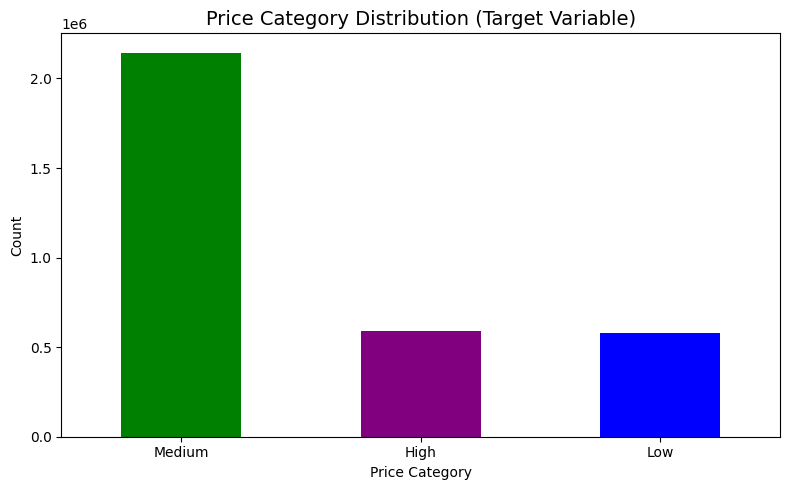

✅ Target variable created!


In [6]:
# Create 3 price categories
df['PRICE_CATEGORY'] = pd.cut(
    df['PRODUCT_PRICE'],
    bins=[0, 175, 210, 400],
    labels=['Low', 'Medium', 'High']
)

# Check distribution
print("\n=== Price Category Distribution ===")
print(df['PRICE_CATEGORY'].value_counts())
print("\n=== Percentage ===")
print(df['PRICE_CATEGORY'].value_counts(normalize=True).round(3) * 100)

# Visualise class distribution
plt.figure(figsize=(8, 5))
df['PRICE_CATEGORY'].value_counts().plot(kind='bar', 
    color=['green', 'purple', 'blue'])
plt.title('Price Category Distribution (Target Variable)', fontsize=14)
plt.xlabel('Price Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✅ Target variable created!")

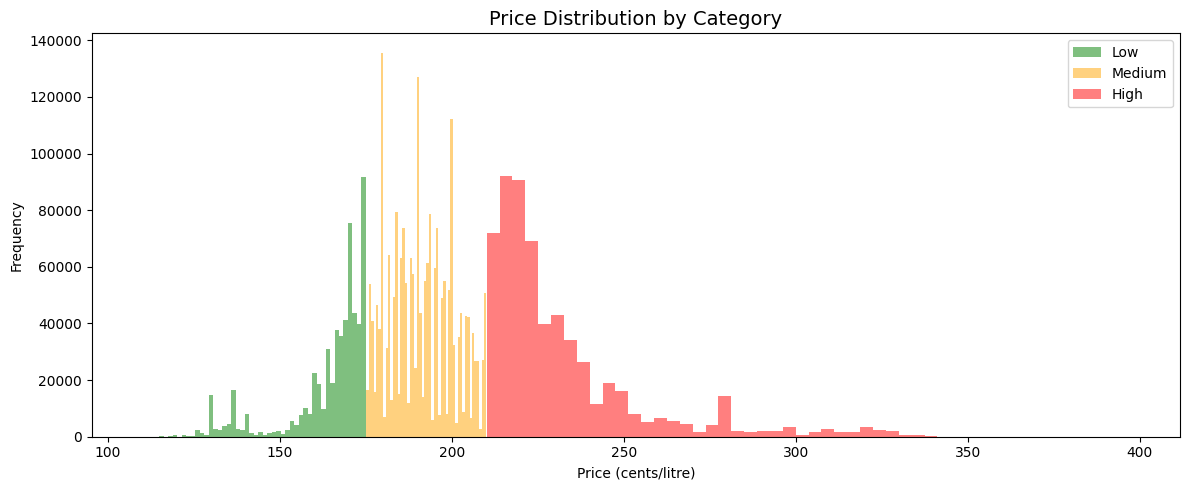

In [16]:
# Plot 1: Price distribution by category
plt.figure(figsize=(12, 5))
for cat, color in zip(['Low', 'Medium', 'High'], 
                       ['green', 'orange', 'red']):
    subset = df[df['PRICE_CATEGORY'] == cat]['PRODUCT_PRICE']
    plt.hist(subset, bins=50, alpha=0.5, 
             label=cat, color=color)
plt.title('Price Distribution by Category', fontsize=14)
plt.xlabel('Price (cents/litre)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('price_by_category.png', dpi=150)
plt.show()

<Figure size 1400x600 with 0 Axes>

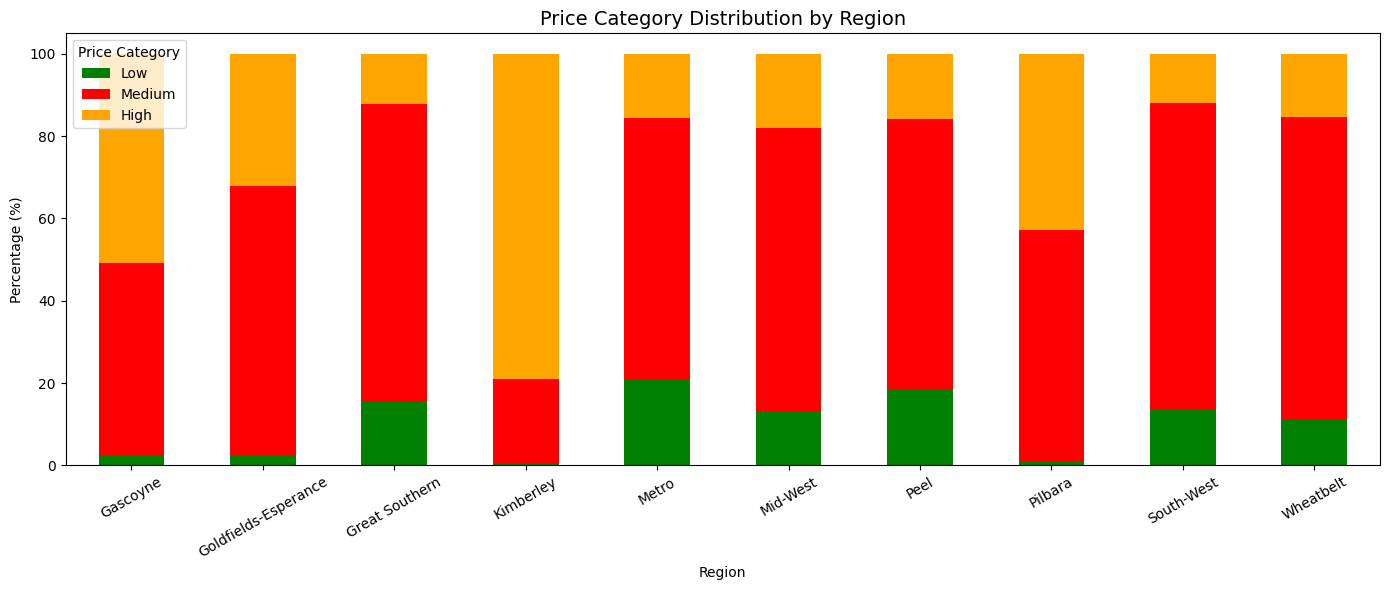

In [17]:
# Plot 2: Category by Region
plt.figure(figsize=(14, 6))
region_cat = df.groupby(['REGION_DESCRIPTION', 
    'PRICE_CATEGORY']).size().unstack(fill_value=0)
region_cat_pct = region_cat.div(
    region_cat.sum(axis=1), axis=0) * 100
region_cat_pct.plot(kind='bar', stacked=True, 
    color=['green', 'red', 'orange'],
    figsize=(14, 6))
plt.title('Price Category Distribution by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Percentage (%)')
plt.legend(title='Price Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('category_by_region.png', dpi=150)
plt.show()

<Figure size 1200x600 with 0 Axes>

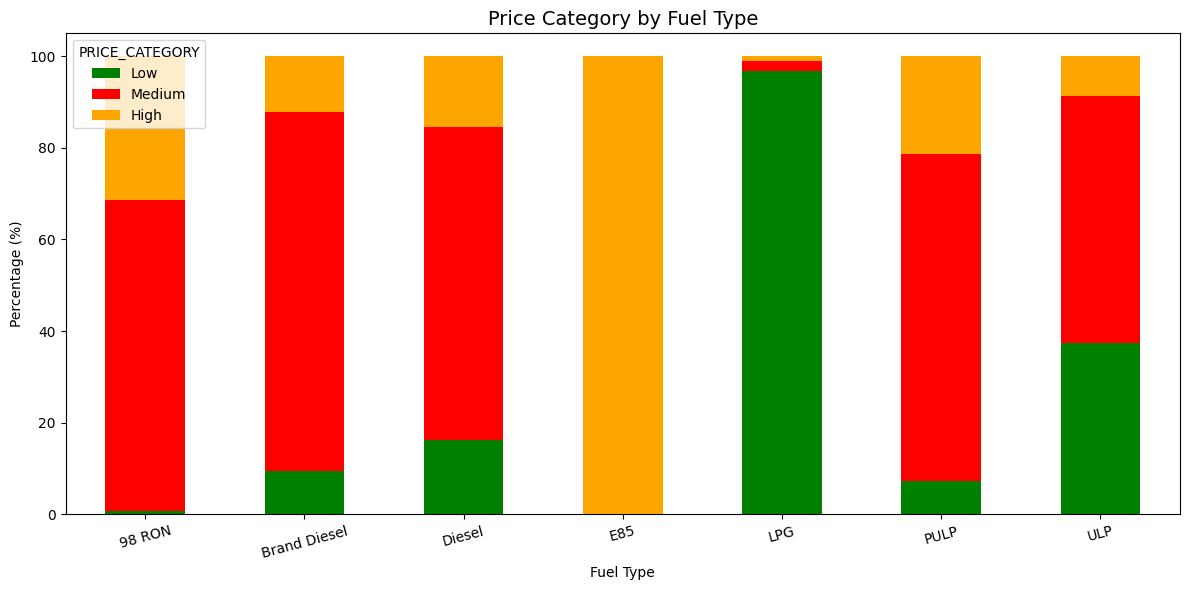

In [18]:
# Plot 3: Category by Fuel Type
plt.figure(figsize=(12, 6))
fuel_cat = df.groupby(['PRODUCT_DESCRIPTION', 
    'PRICE_CATEGORY']).size().unstack(fill_value=0)
fuel_cat_pct = fuel_cat.div(
    fuel_cat.sum(axis=1), axis=0) * 100
fuel_cat_pct.plot(kind='bar', stacked=True,
    color=['green', 'red', 'orange'],
    figsize=(12, 6))
plt.title('Price Category by Fuel Type', fontsize=14)
plt.xlabel('Fuel Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('category_by_fuel.png', dpi=150)
plt.show()

In [12]:
# Fix imports
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("✅ Libraries imported!")

✅ Libraries imported!


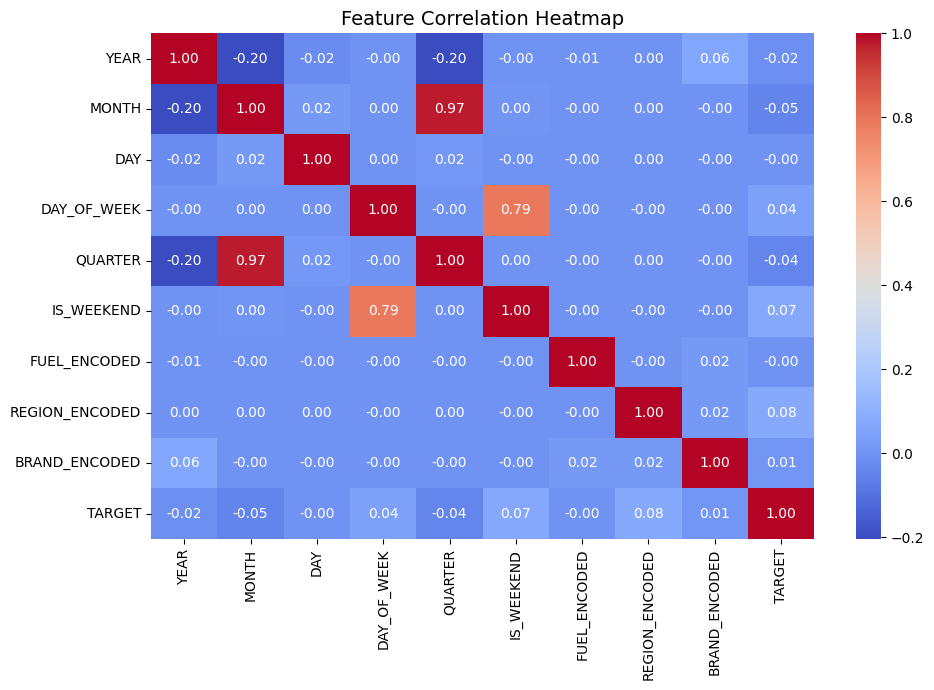

✅ Heatmap saved!


In [19]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_df = df[features + ['TARGET']]
sns.heatmap(numeric_df.corr(), annot=True,
            fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [20]:
# ── Model 1: Logistic Regression (FIXED) ──────────
print("\n⏳ Training Model 1: Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
    # removed multi_class parameter — not needed in newer sklearn
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("✅ Model 1: Logistic Regression done!")

# ── Model 2: Decision Tree ─────────────────────────
print("\n⏳ Training Model 2: Decision Tree...")
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("✅ Model 2: Decision Tree done!")

# ── Model 3: Random Forest ─────────────────────────
print("\n⏳ Training Model 3: Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("✅ Model 3: Random Forest done!")

print("\n🎉 All 3 models trained!")


⏳ Training Model 1: Logistic Regression...
✅ Model 1: Logistic Regression done!

⏳ Training Model 2: Decision Tree...
✅ Model 2: Decision Tree done!

⏳ Training Model 3: Random Forest...
✅ Model 3: Random Forest done!

🎉 All 3 models trained!


In [21]:
# Date features
df['YEAR'] = df['PUBLISH_DATE'].dt.year
df['MONTH'] = df['PUBLISH_DATE'].dt.month
df['DAY'] = df['PUBLISH_DATE'].dt.day
df['DAY_OF_WEEK'] = df['PUBLISH_DATE'].dt.dayofweek
df['QUARTER'] = df['PUBLISH_DATE'].dt.quarter
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(
    lambda x: 1 if x >= 5 else 0)

# Encode categorical columns
le_fuel = LabelEncoder()
le_region = LabelEncoder()
le_brand = LabelEncoder()

df['FUEL_ENCODED'] = le_fuel.fit_transform(df['PRODUCT_DESCRIPTION'])
df['REGION_ENCODED'] = le_region.fit_transform(df['REGION_DESCRIPTION'])
df['BRAND_ENCODED'] = le_brand.fit_transform(df['BRAND_DESCRIPTION'])

# Encode target
le_target = LabelEncoder()
df['TARGET'] = le_target.fit_transform(df['PRICE_CATEGORY'])

print("✅ Features created!")
print(f"Classes: {le_target.classes_}")
print(f"\nFeature list:")
features = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 
            'QUARTER', 'IS_WEEKEND', 'FUEL_ENCODED', 
            'REGION_ENCODED', 'BRAND_ENCODED']
print(features)

✅ Features created!
Classes: ['High' 'Low' 'Medium']

Feature list:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'QUARTER', 'IS_WEEKEND', 'FUEL_ENCODED', 'REGION_ENCODED', 'BRAND_ENCODED']


In [22]:
def evaluate_classifier(name, y_test, y_pred, model, X_test):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
        target_names=le_target.classes_))
    
    return acc, prec, rec, f1

# Evaluate all models
acc_lr, prec_lr, rec_lr, f1_lr = evaluate_classifier(
    "Logistic Regression", y_test, y_pred_lr, lr, X_test)

acc_dt, prec_dt, rec_dt, f1_dt = evaluate_classifier(
    "Decision Tree", y_test, y_pred_dt, dt, X_test)

acc_rf, prec_rf, rec_rf, f1_rf = evaluate_classifier(
    "Random Forest", y_test, y_pred_rf, rf, X_test)


  Logistic Regression
  Accuracy  : 0.6555 (65.55%)
  Precision : 0.7039
  Recall    : 0.6555
  F1 Score  : 0.5444

  Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.00      0.00     17916
         Low       0.57      0.12      0.20     17421
      Medium       0.66      0.98      0.79     64663

    accuracy                           0.66    100000
   macro avg       0.74      0.37      0.33    100000
weighted avg       0.70      0.66      0.54    100000


  Decision Tree
  Accuracy  : 0.8187 (81.87%)
  Precision : 0.8169
  Recall    : 0.8187
  F1 Score  : 0.8130

  Classification Report:
              precision    recall  f1-score   support

        High       0.80      0.69      0.74     17916
         Low       0.80      0.59      0.68     17421
      Medium       0.83      0.91      0.87     64663

    accuracy                           0.82    100000
   macro avg       0.81      0.73      0.76    100000
weighted avg   

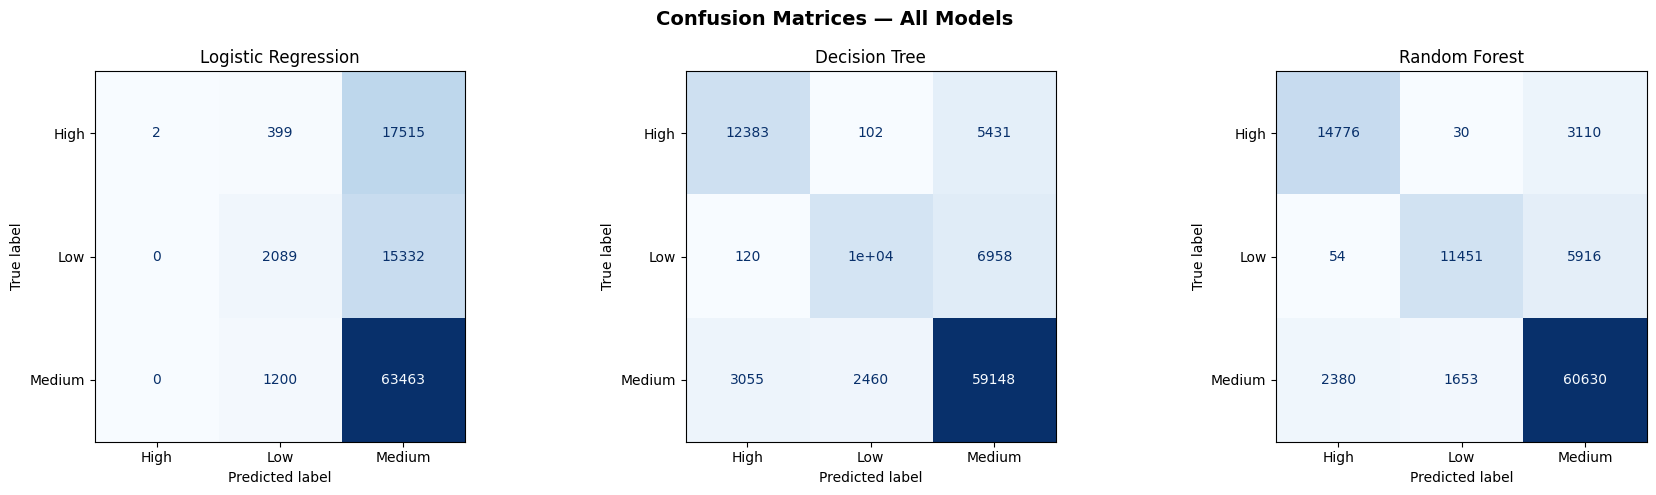

Confusion matrices saved!


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le_target.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices — All Models', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrices saved!")

In [25]:
print("⏳ Running Cross Validation (5-fold)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [
    ("Logistic Regression", lr),
    ("Decision Tree", dt),
    ("Random Forest", rf)
]:
    scores = cross_val_score(
        model, X_scaled[:100000], 
        y_sample[:100000],
        cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"\n{name}:")
    print(f"  CV Scores: {scores.round(4)}")
    print(f"  Mean: {scores.mean():.4f} "
          f"(+/- {scores.std():.4f})")

print("\n Cross validation complete!")

⏳ Running Cross Validation (5-fold)...

Logistic Regression:
  CV Scores: [0.6542 0.6549 0.6538 0.6546 0.6544]
  Mean: 0.6544 (+/- 0.0004)

Decision Tree:
  CV Scores: [0.8206 0.8081 0.8145 0.8139 0.8136]
  Mean: 0.8141 (+/- 0.0040)

Random Forest:
  CV Scores: [0.858  0.8582 0.8584 0.8607 0.8548]
  Mean: 0.8580 (+/- 0.0019)

 Cross validation complete!
